In [8]:
# Cell 1: Setup
import numpy as np
import matplotlib.pyplot as plt
# Set random seed so results are reproducible
np.random.seed(42)
# Define our possible objects
OBJECTS = ["cup", "ball", "book", "phone", "apple"]
print("Possible objects:", OBJECTS)

Possible objects: ['cup', 'ball', 'book', 'phone', 'apple']


In [9]:
# Cell 2: Create sensory input
def create_sensory_input(true_object, num_columns, noise_level=0.3):
 """
 Creates evidence that each column receives.

 Parameters:
 - true_object: The object that's actually present (index)
 - num_columns: How many columns we have
 - noise_level: How much noise/ambiguity (0-1)

 Returns:
 - evidence: Array of shape (num_columns, num_objects)
 Each row is one column's evidence for each object
 """
 num_objects = len(OBJECTS)

 # Start with random noise
 evidence = np.random.uniform(0, noise_level, (num_columns,
num_objects))

 # Add strong signal for the true object (with variation per column)
 for col in range(num_columns):
 # Each column gets slightly different evidence
         signal_strength = np.random.uniform(0.5, 1.0)
 evidence[col, true_object] += signal_strength

 # Normalize so each column's evidence sums to 1 (like probabilities)
 evidence = evidence / evidence.sum(axis=1, keepdims=True)


 return evidence
# Test it!
true_object = 0 # The true object is "cup"
num_columns = 6
evidence = create_sensory_input(true_object, num_columns)
print(f"True object: {OBJECTS[true_object]}")
print(f"\nEvidence matrix (columns x objects):")
print(f"Objects: {OBJECTS}")
for i, col_evidence in enumerate(evidence):
 print(f"Column {i}: {np.round(col_evidence, 2)}")

True object: cup

Evidence matrix (columns x objects):
Objects: ['cup', 'ball', 'book', 'phone', 'apple']
Column 0: [0.13 0.34 0.26 0.21 0.06]
Column 1: [0.07 0.02 0.36 0.25 0.3 ]
Column 2: [0.01 0.44 0.38 0.1  0.08]
Column 3: [0.11 0.18 0.3  0.25 0.17]
Column 4: [0.33 0.07 0.16 0.2  0.24]
Column 5: [0.74 0.04 0.1  0.11 0.01]


In [11]:
# Cell 3: Initialize beliefs
def initialize_beliefs(evidence):
    """
    Initialize each column's beliefs from its sensory evidence.
    Beliefs are just a copy of evidence initially.
    """
    return evidence.copy()
 # Initialize
beliefs = initialize_beliefs(evidence)
print("Initial beliefs (same as evidence):")
for i, col_beliefs in enumerate(beliefs):
    best_guess = OBJECTS[np.argmax(col_beliefs)]
    confidence = np.max(col_beliefs)
    print(f"Column {i}: Best guess = {best_guess} ({confidence:.1%} confident)")

Initial beliefs (same as evidence):
Column 0: Best guess = ball (33.8% confident)
Column 1: Best guess = book (36.3% confident)
Column 2: Best guess = ball (43.7% confident)
Column 3: Best guess = book (30.2% confident)
Column 4: Best guess = cup (32.8% confident)
Column 5: Best guess = cup (73.7% confident)


In [14]:
# Cell 4: Voting mechanism
def voting_round(beliefs, evidence, vote_weight=0.3):
    """
    One round of voting among columns.

    Parameters:
    - beliefs: Current beliefs (num_columns x num_objects)
    - evidence: Original sensory evidence
    - vote_weight: How much to weight neighbors' votes (0-1)

    Returns:
    - new_beliefs: Updated beliefs after voting
    """
    num_columns = beliefs.shape[0]
    new_beliefs = np.zeros_like(beliefs)

    for col in range(num_columns):
        # Start with this column's own evidence
        own_contribution = (1 - vote_weight) * evidence[col]

        # Gather votes from ALL other columns
        other_columns = [i for i in range(num_columns) if i != col]
        votes = beliefs[other_columns].mean(axis=0) # Average vote
        vote_contribution = vote_weight * votes

        # Combine own evidence with votes
        new_beliefs[col] = own_contribution + vote_contribution

    # Normalize
    new_beliefs = new_beliefs / new_beliefs.sum(axis=1, keepdims=True)

    return new_beliefs
# Test one round
new_beliefs = voting_round(beliefs, evidence)
print("After 1 voting round:")
for i, col_beliefs in enumerate(new_beliefs):
    best_guess = OBJECTS[np.argmax(col_beliefs)]
    confidence = np.max(col_beliefs)
    print(f"Column {i}: Best guess = {best_guess} ({confidence:.1%})")

After 1 voting round:
Column 0: Best guess = ball (28.2%)
Column 1: Best guess = book (32.5%)
Column 2: Best guess = ball (34.5%)
Column 3: Best guess = book (28.7%)
Column 4: Best guess = cup (29.3%)
Column 5: Best guess = cup (55.5%)


In [17]:
# Cell 5: Run to consensus
def run_voting(evidence, max_iterations=20, vote_weight=0.3,
 consensus_threshold=0.9):
 """
 Run voting until consensus or max iterations.

 Parameters:
 - evidence: Sensory input
 - max_iterations: Maximum voting rounds
 - vote_weight: Weight given to neighbor votes
 - consensus_threshold: Stop when this fraction agree

 Returns:
 - history: List of beliefs at each iteration
 - final_object: The consensus object
 - final_confidence: Confidence level
 """
 beliefs = initialize_beliefs(evidence)
 history = [beliefs.copy()]

 for iteration in range(max_iterations):
  # Voting round
  beliefs = voting_round(beliefs, evidence, vote_weight)
  history.append(beliefs.copy())

  # Check for consensus
  predictions = np.argmax(beliefs, axis=1) # Each column's best guess
  most_common = np.bincount(predictions).argmax()

  agreement = (predictions == most_common).mean()

  if agreement >= consensus_threshold:
   print(f"Consensus reached at iteration {iteration + 1}!")
   break

 # Final result
 final_votes = beliefs.mean(axis=0) # Average across columns
 final_object = np.argmax(final_votes)
 final_confidence = final_votes[final_object]

 return history, final_object, final_confidence
# Run it!
history, result, confidence = run_voting(evidence)
print(f"\nFinal result: {OBJECTS[result]}")
print(f"Confidence: {confidence:.1%}")
print(f"True object was: {OBJECTS[true_object]}")
print(f"Correct? {result == true_object}")


Final result: book
Confidence: 26.0%
True object was: cup
Correct? False


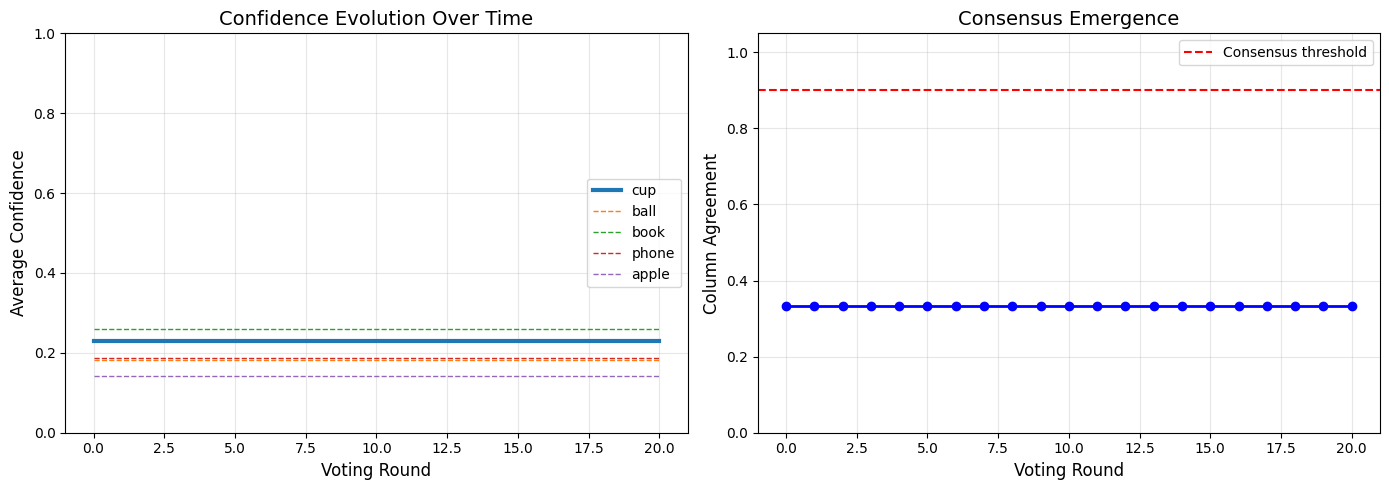

Visualization saved as 'consensus_visualization.png'


In [22]:
# Cell 6: Visualization
def visualize_consensus(history, true_object):
 """
 Create a visualization of how consensus emerges.
 """
 num_iterations = len(history)
 num_columns = history[0].shape[0]
 num_objects = history[0].shape[1]

 # Create figure with 2 subplots
 fig, axes = plt.subplots(1, 2, figsize=(14, 5))

 # Plot 1: Confidence over time for each object
 ax1 = axes[0]
 avg_confidence = np.array([h.mean(axis=0) for h in history])

 for obj_idx in range(num_objects):
  style = '-' if obj_idx == true_object else '--'
  linewidth = 3 if obj_idx == true_object else 1
  ax1.plot(avg_confidence[:, obj_idx], style,
  linewidth=linewidth, label=OBJECTS[obj_idx])

 ax1.set_xlabel('Voting Round', fontsize=12)
 ax1.set_ylabel('Average Confidence', fontsize=12)
 ax1.set_title('Confidence Evolution Over Time', fontsize=14)
 ax1.legend(loc='center right')
 ax1.set_ylim(0, 1)
 ax1.grid(True, alpha=0.3)

 # Plot 2: Agreement level over time
 ax2 = axes[1]
 agreement_over_time = []

 for h in history:
  predictions = np.argmax(h, axis=1)
  most_common = np.bincount(predictions,
  minlength=num_objects).argmax()
  agreement = (predictions == most_common).mean()
  agreement_over_time.append(agreement)

 ax2.plot(agreement_over_time, 'b-', linewidth=2, marker='o')
 ax2.axhline(y=0.9, color='r', linestyle='--', label='Consensus threshold')
 ax2.set_xlabel('Voting Round', fontsize=12)
 ax2.set_ylabel('Column Agreement', fontsize=12)
 ax2.set_title('Consensus Emergence', fontsize=14)
 ax2.legend()
 ax2.set_ylim(0, 1.05)
 ax2.grid(True, alpha=0.3)

 plt.tight_layout()
 plt.savefig('consensus_visualization.png', dpi=150,
 bbox_inches='tight')
 plt.show()

 print("Visualization saved as 'consensus_visualization.png'")
# Create the visualization
visualize_consensus(history, true_object)

In [24]:
# Cell 7: Experiments
# Experiment 1: High noise
print("=" * 50)
print("EXPERIMENT 1: High Noise (noise_level=0.8)")
print("=" * 50)
evidence_noisy = create_sensory_input(true_object, 6, noise_level=0.8)
history_noisy, result_noisy, conf_noisy = run_voting(evidence_noisy)
print(f"Result: {OBJECTS[result_noisy]} ({conf_noisy:.1%})")
print(f"Correct? {result_noisy == true_object}")
# Experiment 2: More columns
print("\n" + "=" * 50)
print("EXPERIMENT 2: More Columns (20 instead of 6)")
print("=" * 50)
evidence_many = create_sensory_input(true_object, 20, noise_level=0.3)
history_many, result_many, conf_many = run_voting(evidence_many)
print(f"Result: {OBJECTS[result_many]} ({conf_many:.1%})")
# Experiment 3: Different vote weights
print("\n" + "=" * 50)
print("EXPERIMENT 3: Vote Weight Comparison")

print("=" * 50)
for weight in [0.1, 0.3, 0.5, 0.7, 0.9]:
 evidence_test = create_sensory_input(true_object, 6, noise_level=0.4)
 _, result_w, conf_w = run_voting(evidence_test, vote_weight=weight)
 correct = "✓" if result_w == true_object else "✗"
 print(f"Weight {weight}: {OBJECTS[result_w]} ({conf_w:.1%}) {correct}")



EXPERIMENT 1: High Noise (noise_level=0.8)
Result: book (26.3%)
Correct? False

EXPERIMENT 2: More Columns (20 instead of 6)
Result: cup (21.9%)

EXPERIMENT 3: Vote Weight Comparison
Weight 0.1: book (28.2%) ✗
Weight 0.3: cup (27.1%) ✓
Weight 0.5: cup (26.6%) ✓
Consensus reached at iteration 1!
Weight 0.7: apple (29.3%) ✗
Weight 0.9: apple (23.1%) ✗
